### Problem Statement
The purpose of this project is to analyze sales data to understand the factors that affect sales and profit. The dataset contains information about products, units sold, sales, profit, discounts, customers, segments, countries, and time periods. The analysis will identify high-performing products, sales and profit trends, and relationships between important variables. The findings will help identify areas for improving sales performance, profitability, and business decision-making.


# Import Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Matplotlib is building the font cache; this may take a moment.


# Load the Dataset

In [39]:
df = pd.read_csv('Dataset.csv')
print(df)

              Segment                   Country    Product Discount Band  \
0          Government                   Germany  Carretera           NaN   
1          Government                   Germany      Paseo           NaN   
2          Government                    Canada      Paseo           NaN   
3          Government                   Germany      Paseo           NaN   
4          Government                   Germany       Velo           NaN   
..                ...                       ...        ...           ...   
695         Midmarket                    Canada      Paseo          High   
696         Midmarket                    Canada      Paseo          High   
697        Enterprise                   Germany      Paseo          High   
698         Midmarket                   Germany      Paseo          High   
699  Channel Partners  United States of America      Paseo          High   

     Units Sold  Manufacturing Price  Sale Price  Gross Sales  Discounts  \
0        15

# Data Cleaning

In [40]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750,448500.0,155250.0,01-Nov-13,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014


In [41]:
df.head(10)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750,448500.0,155250.0,01-Nov-13,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014
5,Government,France,VTT,NaN,1527.0,250,350,534450.0,0.0,534450,397020.0,137430.0,01-Sep-13,September,2013
6,Government,France,Amarilla,NaN,2750.0,260,350,962500.0,0.0,962500,715000.0,247500.0,01-Feb-14,February,2014
7,Government,Mexico,Carretera,Low,1210.0,3,350,423500.0,4235.0,419265,314600.0,104665.0,01-Mar-14,March,2014
8,Government,Mexico,Carretera,Low,1397.0,3,350,488950.0,4889.5,484061,363220.0,120840.5,01-Oct-14,October,2014
9,Government,France,Carretera,Low,2155.0,3,350,754250.0,7542.5,746708,560300.0,186407.5,01-Dec-14,December,2014


In [43]:
df.tail()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name,Year
695,Midmarket,Canada,Paseo,High,1614.0,10,15,24210.0,3631.50,20579,16140.0,4438.50,01-Apr-14,April,2014
696,Midmarket,Canada,Paseo,High,2559.0,10,15,38385.0,5757.75,32627,25590.0,7037.25,01-Aug-14,August,2014
697,Enterprise,Germany,Paseo,High,1085.0,10,125,135625.0,20343.75,115281,130200.0,-14918.75,01-Oct-14,October,2014
698,Midmarket,Germany,Paseo,High,1175.0,10,15,17625.0,2643.75,14981,11750.0,3231.25,01-Oct-14,October,2014
699,Channel Partners,United States of America,Paseo,High,914.0,10,12,10968.0,1645.20,9323,2742.0,6580.80,01-Dec-14,December,2014


In [44]:
df.tail(10)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name,Year
690,Channel Partners,France,Paseo,High,1393.0,10,12,16716.0,2340.24,14376,4179.0,10196.76,01-Oct-14,October,2014
691,Midmarket,Canada,Paseo,High,2470.0,10,15,37050.0,5187.00,31863,24700.0,7163.00,01-Sep-13,September,2013
692,Midmarket,Canada,Paseo,High,1743.0,10,15,26145.0,3660.30,22485,17430.0,5054.70,01-Oct-13,October,2013
693,Channel Partners,United States of America,Paseo,High,2914.0,10,12,34968.0,4895.52,30072,8742.0,21330.48,01-Oct-14,October,2014
694,Channel Partners,Canada,Paseo,High,2222.0,10,12,26664.0,3732.96,22931,6666.0,16265.04,01-Nov-13,November,2013
695,Midmarket,Canada,Paseo,High,1614.0,10,15,24210.0,3631.50,20579,16140.0,4438.50,01-Apr-14,April,2014
696,Midmarket,Canada,Paseo,High,2559.0,10,15,38385.0,5757.75,32627,25590.0,7037.25,01-Aug-14,August,2014
697,Enterprise,Germany,Paseo,High,1085.0,10,125,135625.0,20343.75,115281,130200.0,-14918.75,01-Oct-14,October,2014
698,Midmarket,Germany,Paseo,High,1175.0,10,15,17625.0,2643.75,14981,11750.0,3231.25,01-Oct-14,October,2014
699,Channel Partners,United States of America,Paseo,High,914.0,10,12,10968.0,1645.20,9323,2742.0,6580.80,01-Dec-14,December,2014


In [45]:
df.iloc[:10]

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750,448500.0,155250.0,01-Nov-13,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550,393380.0,136170.0,01-Dec-14,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100,261560.0,90540.0,01-Jun-14,June,2014
5,Government,France,VTT,NaN,1527.0,250,350,534450.0,0.0,534450,397020.0,137430.0,01-Sep-13,September,2013
6,Government,France,Amarilla,NaN,2750.0,260,350,962500.0,0.0,962500,715000.0,247500.0,01-Feb-14,February,2014
7,Government,Mexico,Carretera,Low,1210.0,3,350,423500.0,4235.0,419265,314600.0,104665.0,01-Mar-14,March,2014
8,Government,Mexico,Carretera,Low,1397.0,3,350,488950.0,4889.5,484061,363220.0,120840.5,01-Oct-14,October,2014
9,Government,France,Carretera,Low,2155.0,3,350,754250.0,7542.5,746708,560300.0,186407.5,01-Dec-14,December,2014


In [46]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       ' Sales', 'COGS', 'Profit', 'Date', 'Month Name', 'Year'],
      dtype='object')

In [47]:
df.columns.to_list()

['Segment',
 'Country',
 'Product',
 'Discount Band',
 'Units Sold',
 'Manufacturing Price',
 'Sale Price',
 'Gross Sales',
 'Discounts',
 ' Sales',
 'COGS',
 'Profit',
 'Date',
 'Month Name',
 'Year']

In [48]:
df.shape

(700, 15)

In [49]:
print("Number of rows",df.shape[0])
print("Number of columns",df.shape[1])

Number of rows 700
Number of columns 15


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        647 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    int64  
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Name           700 non-null    object 
 14  Year                 700 non-null    int64  
dtypes: float64(5), int64(4), object(6)
memor

In [51]:
df.dtypes

Segment                 object
Country                 object
Product                 object
Discount Band           object
Units Sold             float64
Manufacturing Price      int64
Sale Price               int64
Gross Sales            float64
Discounts              float64
 Sales                   int64
COGS                   float64
Profit                 float64
Date                    object
Month Name              object
Year                     int64
dtype: object

In [52]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2013.750000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367264e+05,203865.506118,42760.626563,0.433322
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655000e+03,918.000000,-40617.500000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554050e+04,22506.250000,9242.200000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014.000000


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,700.0,1608.294286,867.427859,200.0,905.00,1542.50,2229.12500,4492.5
Manufacturing Price,700.0,96.477143,108.602612,3.0,5.00,10.00,250.00000,260.0
Sale Price,700.0,118.428571,136.775515,7.0,12.00,20.00,300.00000,350.0
Gross Sales,700.0,182759.426429,254262.284378,1799.0,17391.75,37980.00,279025.00000,1207500.0
Discounts,700.0,13150.354629,22962.928775,0.0,800.32,2585.25,15956.34375,149677.5
Sales,700.0,169609.121429,236726.363843,1655.0,15928.00,35540.50,261077.50000,1159200.0
COGS,700.0,145475.211429,203865.506118,918.0,7490.00,22506.25,245607.50000,950625.0
Profit,700.0,24133.860371,42760.626563,-40617.5,2805.96,9242.20,22662.00000,262200.0
Year,700.0,2013.750000,0.433322,2013.0,2013.75,2014.00,2014.00000,2014.0


In [54]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Name              0
Year                    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

# Handling Missing Values

In [55]:
df_filled = df.copy()

df_filled["Units Sold"] = df_filled["Units Sold"].fillna(df_filled["Units Sold"].mean())
print(df_filled["Units Sold"])

0      1513.0
1      1006.0
2      1725.0
3      1513.0
4      1006.0
        ...  
695    1614.0
696    2559.0
697    1085.0
698    1175.0
699     914.0
Name: Units Sold, Length: 700, dtype: float64


In [56]:
df_filled = df.copy()

df_filled["Sale Price"] = df_filled["Sale Price"].fillna(df_filled["Sale Price"].mean())
print(df_filled["Sale Price"])

0      350
1      350
2      350
3      350
4      350
      ... 
695     15
696     15
697    125
698     15
699     12
Name: Sale Price, Length: 700, dtype: int64


In [57]:
df_filled = df.copy()

df_filled["Manufacturing Price"] = df_filled["Manufacturing Price"].fillna(df_filled["Manufacturing Price"].median())
print(df_filled["Manufacturing Price"])

0        3
1       10
2       10
3       10
4      120
      ... 
695     10
696     10
697     10
698     10
699     10
Name: Manufacturing Price, Length: 700, dtype: int64


# EDA

# Which segment has the highest sales?

In [116]:
segment = df.groupby("Segment")[" Sales"].mean()
print("Highest Sales of Segment" , segment)

Highest Sales of Segment Segment
Channel Partners     18005.940000
Enterprise          196117.050000
Government          175014.276667
Midmarket            23818.830000
Small Business      424279.200000
Name:  Sales, dtype: float64


In [117]:
segment = df.groupby("Segment")[" Sales"].mean().idxmax()
print("Highest Sales  Segment" , segment)

Highest Sales of Segment Small Business


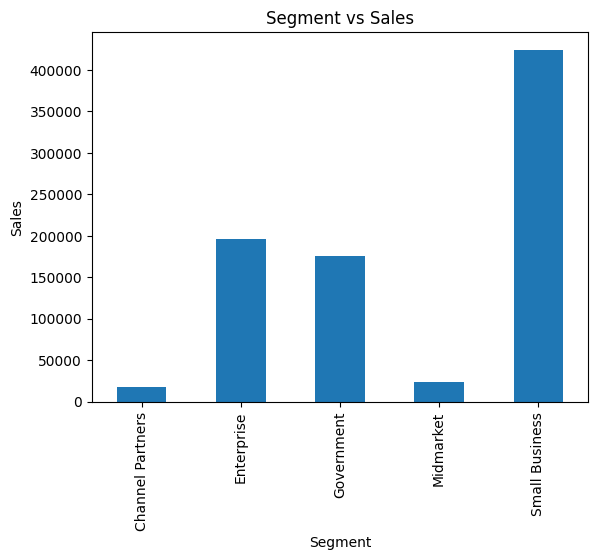

In [132]:
segment = df.groupby("Segment")[" Sales"].mean().plot.bar()
plt.title("Segment vs Sales")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

# Which country has the lowest sales?

In [114]:
country = df.groupby("Country")[" Sales"].mean()
print("Lowest Sales of Country", country)

Lowest Sales of Country Country
Canada                      177769.000000
France                      173958.442857
Germany                     167895.371429
Mexico                      149638.264286
United States of America    178784.528571
Name:  Sales, dtype: float64


In [115]:
country = df.groupby("Country")[" Sales"].mean().idxmin()
print("Lowest Sales of Country", country)

Lowest Sales of Country Mexico


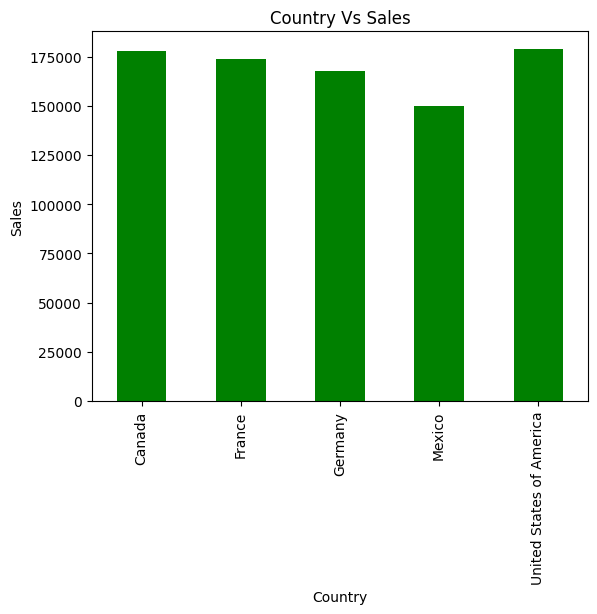

In [133]:
country = df.groupby("Country")[" Sales"].mean().plot.bar(color="green")
plt.title("Country Vs Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

# Which Product has the Highest Sales

In [118]:
product = df.groupby("Product")[" Sales"].mean()
print("Product with highest sales",product)

Product with highest sales Product
Amarilla     188799.127660
Carretera    148551.752688
Montana      165492.548387
Paseo        163421.549505
VTT          188182.825688
Velo         167431.798165
Name:  Sales, dtype: float64


In [119]:
product = df.groupby("Product")[" Sales"].mean().idxmax()
print("Product with highest sales",product)

Product with highest sales Amarilla


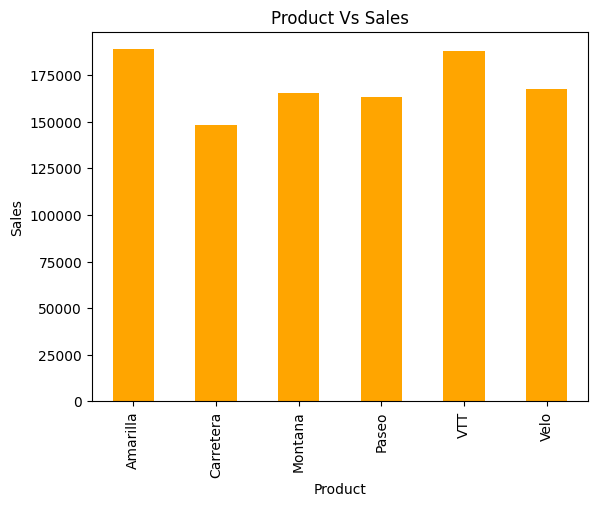

In [135]:
product = df.groupby("Product")[" Sales"].mean().plot.bar(color="Orange")
plt.title("Product Vs Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

# Which product has highest in the profit

In [77]:
profit = df.groupby("Product")["Profit"].mean()
print("Product with Highest Profit", profit)

Highest Number of Profit in the Product Product
Amarilla     29937.277234
Carretera    19643.063280
Montana      22739.299785
Paseo        23749.692822
VTT          27840.440550
Velo         21155.894174
Name: Profit, dtype: float64


In [121]:
profit = df.groupby("Product")["Profit"].mean().idxmax()
print("Product with Highest Profit", profit)

Product with Highest Profit Amarilla


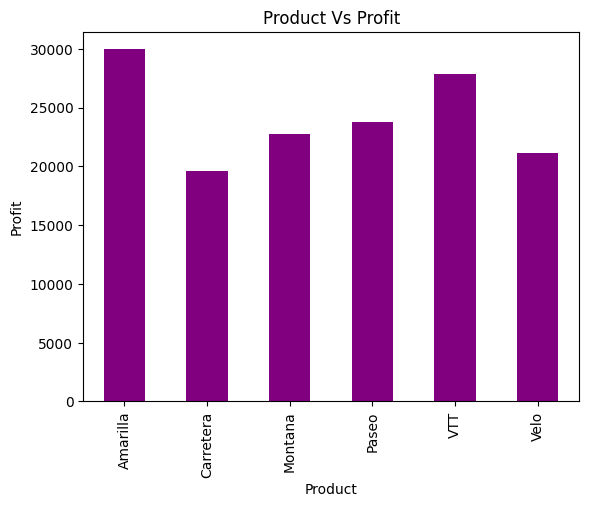

In [136]:
profit = df.groupby("Product")["Profit"].mean().plot.bar(color="purple")
plt.title("Product Vs Profit")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.show()

# Which Year has highest in the Sales

In [123]:
year = df.groupby("Year")[" Sales"].mean()
print("Year with highest sales", year)

Year with highest sales Year
2013    150944.388571
2014    175830.699048
Name:  Sales, dtype: float64


In [124]:
year = df.groupby("Year")[" Sales"].mean().idxmax()
print("Year with highest sales", year)

Year with highest sales 2014


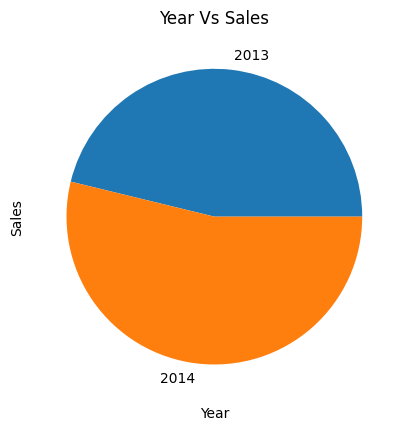

In [137]:
year = df.groupby("Year")[" Sales"].mean().plot.pie()
plt.title("Year Vs Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

# Which product has the highest units sold?

In [125]:
Units_sold = df.groupby("Product")["Units Sold"].mean()
print("Highest number of units sold:", Units_sold)

Highest number of units sold: Product
Amarilla     1652.287234
Carretera    1578.989247
Montana      1658.043011
Paseo        1674.452970
VTT          1548.467890
Velo         1490.133028
Name: Units Sold, dtype: float64


In [126]:
Units_sold = df.groupby("Product")["Units Sold"].mean().idxmax()
print("Highest number of units sold:", Units_sold)

Highest number of units sold: Paseo


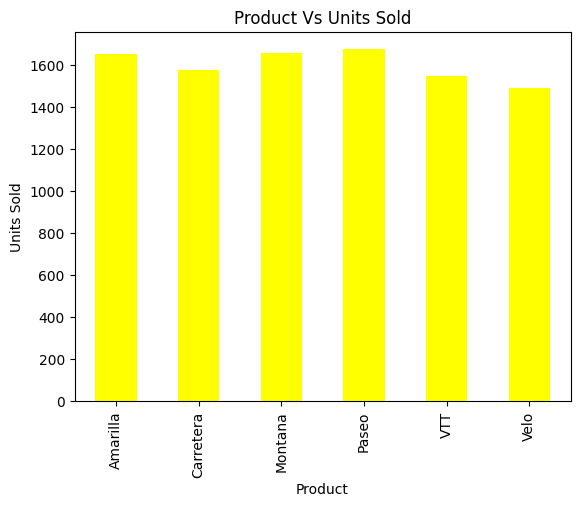

In [139]:
Units_sold = df.groupby("Product")["Units Sold"].mean().plot.bar(color="yellow")
plt.title("Product Vs Units Sold")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()

# What are the major sales and profit trends in the dataset?

In [92]:
country = df.groupby("Country")[[" Sales" ,"Profit"]].sum()
print(country)

                             Sales       Profit
Country                                        
Canada                    24887660  3529228.885
France                    24354182  3781020.780
Germany                   23505352  3680388.820
Mexico                    20949357  2907523.110
United States of America  25029834  2995540.665


In [96]:
year = df.groupby("Year")[[" Sales" ,"Profit"]].sum()
print(year)

         Sales       Profit
Year                       
2013  26415268   3878464.51
2014  92311117  13015237.75


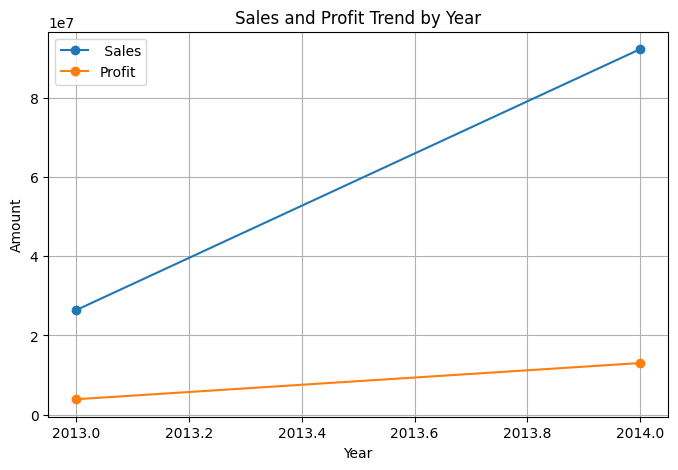

In [108]:
import matplotlib.pyplot as plt

year.plot(kind="line", marker="o", figsize=(8, 5))

plt.title("Sales and Profit Trend by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

In [97]:
segment = df.groupby("Segment")[[" Sales" ,"Profit"]].sum()
print(segment)

                     Sales        Profit
Segment                                 
Channel Partners   1800594  1.316803e+06
Enterprise        19611705 -6.145456e+05
Government        52504283  1.138817e+07
Midmarket          2381883  6.601031e+05
Small Business    42427920  4.143168e+06


In [98]:
product = df.groupby("Product")[[" Sales" ,"Profit"]].sum()
print(product)

              Sales       Profit
Product                         
Amarilla   17747118  2814104.060
Carretera  13815313  1826804.885
Montana    15390807  2114754.880
Paseo      33011153  4797437.950
VTT        20511928  3034608.020
Velo       18250066  2305992.465


# Are there any outliers in Sales, Profit, or Units Sold?

<Axes: ylabel=' Sales'>

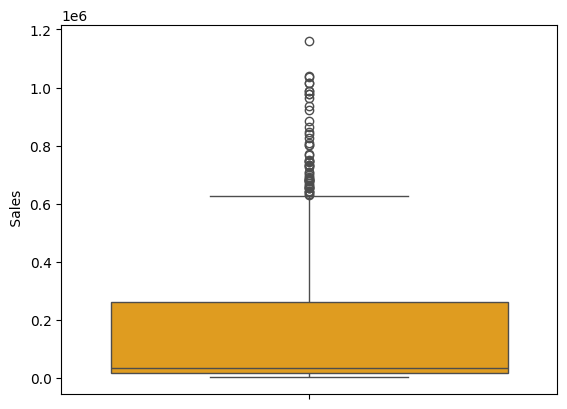

In [145]:
sns.boxplot(y=" Sales" ,data=df,color="Orange")

<Axes: ylabel='Profit'>

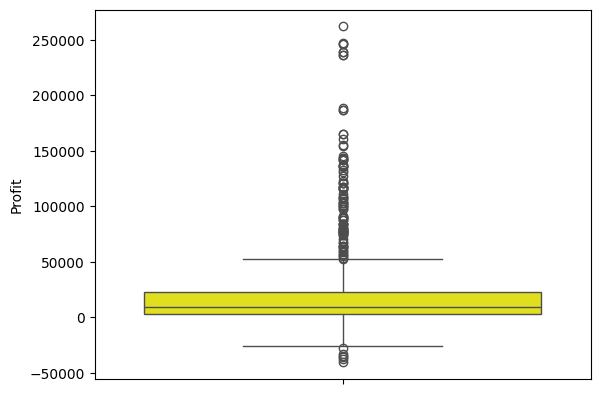

In [146]:
sns.boxplot(y="Profit",data=df,color="yellow")

<Axes: ylabel='Units Sold'>

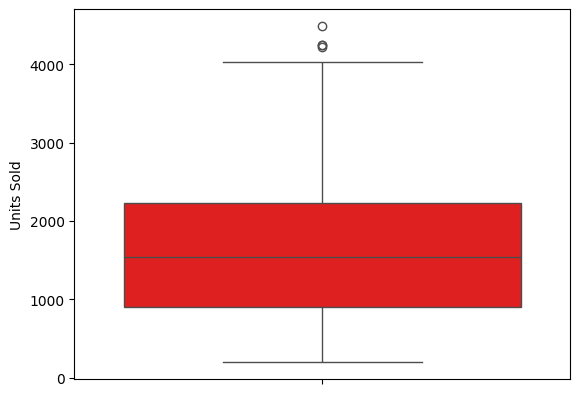

In [147]:
sns.boxplot(y="Units Sold",data=df,color="red")

# What is the correlation between Units Sold, Sales, COGS, and Profit?

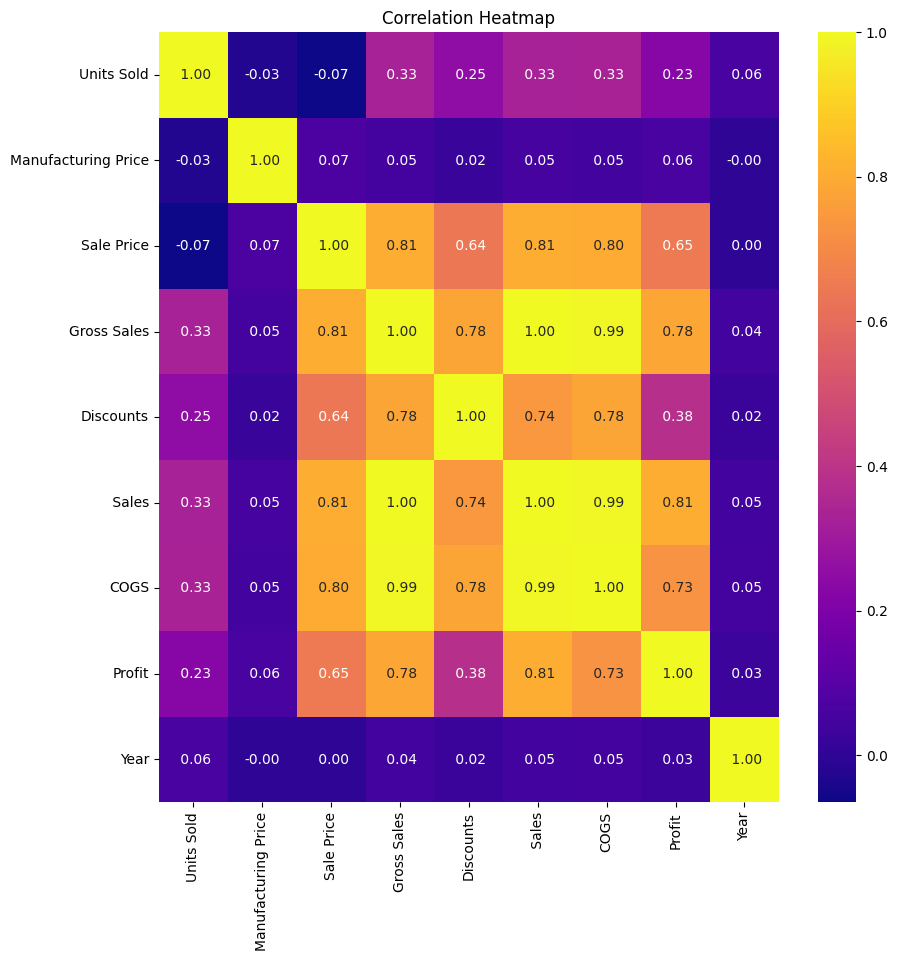

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
correlation = df.corr(numeric_only =True)
sns.heatmap (
    correlation,
    annot=True,
    cmap='plasma',
    fmt=" .2f"
)
plt.title("Correlation Heatmap")
plt.show()

1) Gross Sales ↔ Sales ↔ COGS (≈0.99–1.00): Near-perfect correlation — expected, since Sales is derived from Gross Sales minus Discounts, and COGS scales directly with sales volume.
2) Gross Sales/Sales ↔ Profit (0.78–0.81): Strong positive relationship — higher sales generally drive higher profit, though not perfectly, since discounts and costs eat into margins.
3) Discounts ↔ Gross Sales/Sales (0.74–0.78): Higher discounts are associated with higher gross sales — likely because discounts are applied more on large-volume deals, not that discounting causes more sales.
4) Discounts ↔ Profit (0.38): Only a moderate relationship, weaker than Discounts ↔ Sales — suggesting heavy discounting boosts revenue but doesn't proportionally boost profit (it erodes margin).
5) Sale Price ↔ Profit (0.65): Moderately strong — pricing has a meaningful but not dominant effect on profitability.
6) Units Sold ↔ most variables (0.23–0.33): Surprisingly weak correlation with Sales/Profit — implying revenue is driven more by price and product mix than raw unit volume.
7) Manufacturing Price: Very weak correlation with almost everything (≈0.00–0.07) — manufacturing cost doesn't vary much with sales performance in this dataset.
8) Year: Near-zero correlation with all variables — no strong time-based trend captured here (makes sense, since correlation only checks linear year-over-year scaling, not seasonal patterns).

# Create a regression model to predict sales

In [150]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Dataset.csv")

# Input and target
X = df[['Units Sold']]
y = df[' Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict sales
y_pred = model.predict(X_test)

# Check model performance
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict sales for a new quantity
new_quantity = [[10]]
prediction = model.predict(new_quantity)

print("Predicted Sales:", prediction[0])



R2 Score: 0.06535564527077464
Mean Squared Error: 51763524938.18301
Predicted Sales: 18040.775477365438


c:\users\krishnamohan b\appdata\local\programs\python\python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Write a short summary of findings & recommendations.

# Summary of Findings
The analysis reveals some significant differences in terms of sales and profits by product, year, country, and customer segment. Certain products contribute much more towards total sales and profit than others. Units sold are shown to have an important relationship with sales, although there may be impacts from discounts affecting profit margins. Analysis at a year- and month-wise level allows us to see periods of increased sales performance.
# Recommentations
High performing products/customer segments should focus efforts upon to increase sales & profitability as required. It would seem prudent to monitor levels of discounting in order to prevent unwarranted reductions in profit margins. It will be necessary to analyze low performing products and regions in search of avenues of improvements. Sales Trends could assist planning for inventories and marketing activities and sales strategy's for high demand times.